# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [ ]:
titanic = pd.read_csv("data/titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    str     
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    str     
 12  Familia      891 non-null    int64   
 13  Age_Group    714 non-null    category
 14  Persona      891 non-null    str     
dtypes: category(1), float64(2), int64(6), str(6)
memory usage: 98.7 KB


#### **cuáles variables son numéricas y cuáles son categóricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?  891
- ¿Qué características contiene la base de datos?  ID, Age, Sex, Survived, Pclass, Name, Familie, Ticket, Fare...
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


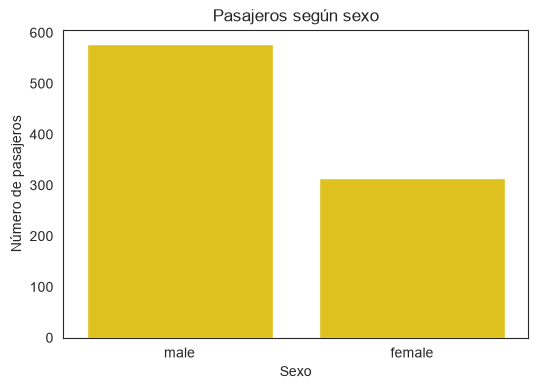

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?

La tercera clase contiene la mayoridad de los pasajeros, en la tercera son mas que en los otras clases juntas.



<Axes: xlabel='Pclass', ylabel='count'>

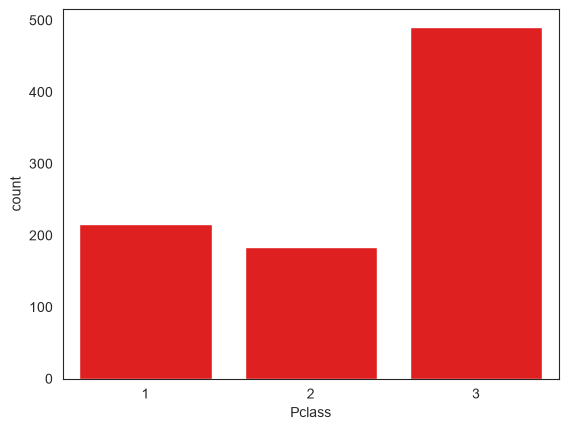

In [8]:
sns.countplot(data=titanic, x="Pclass", color="red")


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?                       entre 17 y 40 son las edades ma frecuentes
- ¿La distribución parece simétrica?                    no, no es simétrica, hay mas personos con un edad bajo, que con un edad mayor. 
- ¿El número de bins cambia su interpretación?          no mucho


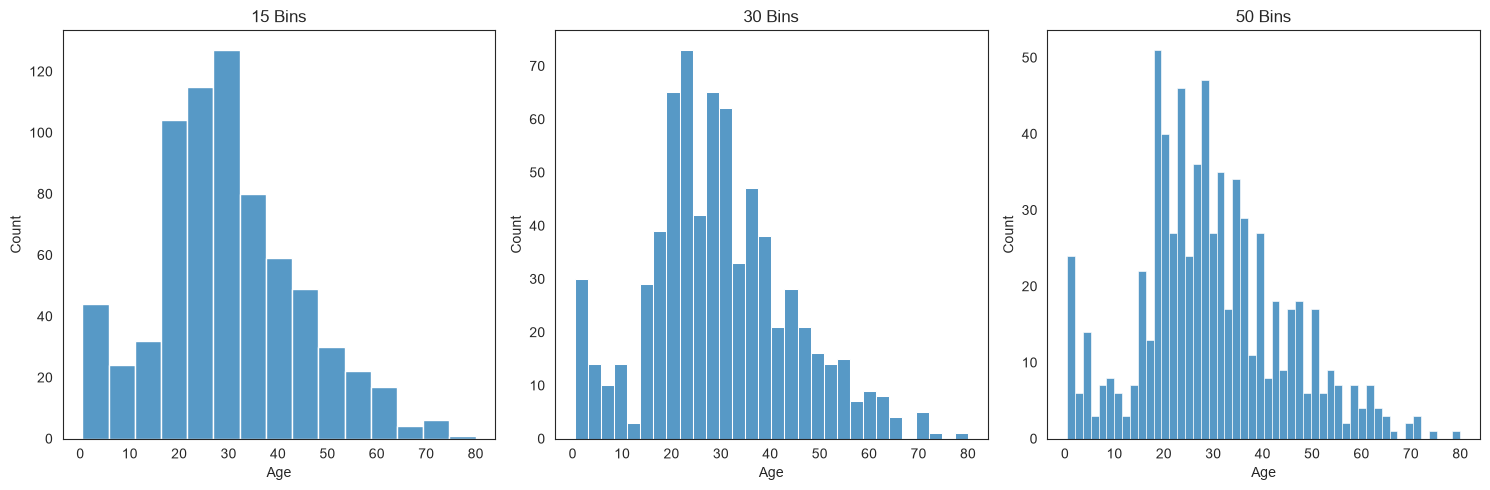

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# first plot
sns.histplot(data=titanic, x="Age", bins=15, ax=axes[0])
axes[0].set_title("15 Bins")

# Second plot
sns.histplot(data=titanic, x="Age", bins=30, ax=axes[1])
axes[1].set_title("30 Bins")

# Third plot
sns.histplot(data=titanic, x="Age", bins=50, ax=axes[2])
axes[2].set_title("50 Bins")

plt.tight_layout()
plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?




*  la distribution no es symetrica, es sesgada a la derecha
*  Si hay outliers, con tarifa muy alto
*  La asimetría positiva es consistente con el hecho de que muchos más viajaban en tercera clase.




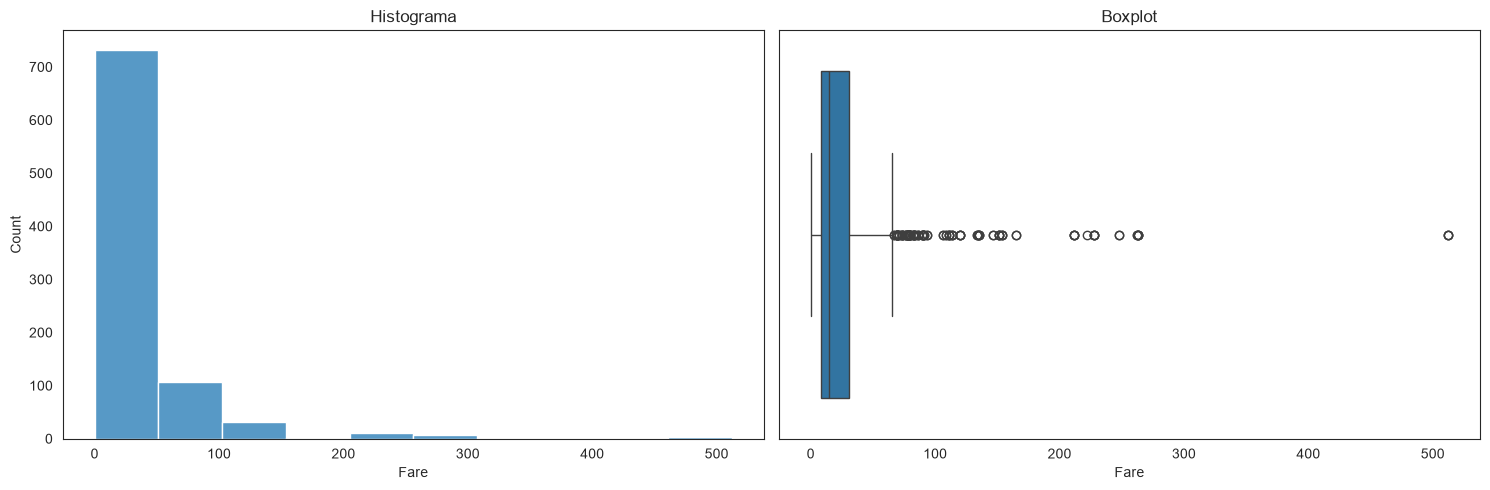

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=titanic, x="Fare", bins=10, ax=axes[0])
axes[0].set_title("Histograma")

sns.boxplot(data=titanic, x="Fare", ax=axes[1])
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [26]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Familia          0
dtype: int64

In [27]:
687/891

0.7710437710437711

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


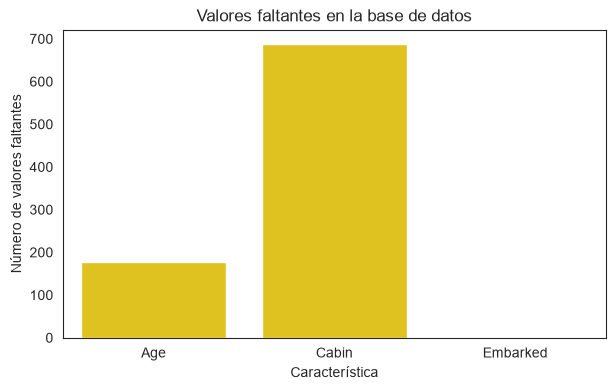

In [12]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?   
-> Si son casi lo mismo
- Es la media una buena representación de una edad típica?
-> Sí porque la mediana y la media son similares y la distribution del edad es symtrico


In [13]:
media = titanic["Age"].mean()
mediana = titanic["Age"].median()

print(f"Media:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")

Media:   29.70
Mediana: 28.00


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?

Se podrían reemplazar los edades faltantes por datos aleatorios usando la misma media y dispersión que la distribución original.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.

Rellenar los datos no es una buena idea, porque faltan mas de 77% de los datos. Es possible eliminar la categoria o tambien usar como un valor bool si es conocido o no.
Sí puede ser, que mas para los pasageros en clase 1 o 2 la cabina es conocido, y ademas la ubicacion de la cabina es informacion importante



**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?

reemplazar las valors faltates por el valor mas frecuente.
y el tratamiento es distinto porque solo faltan 2 / 891 datos lo cual no altera significativamente la distribución general



# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


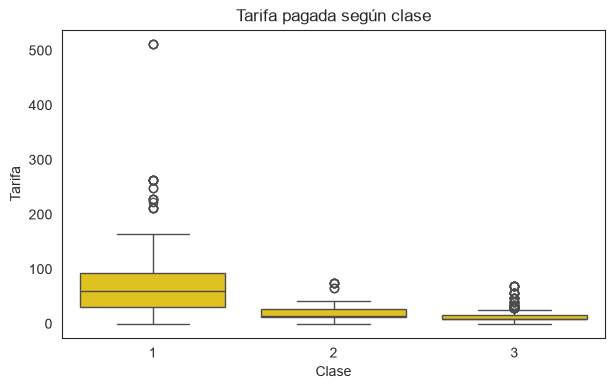

In [14]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?      Sí las tarifas in clase uno son mas alto que en los otras clases
- Hay dispersión dentro de cada clase?                  en clase dos y tres la dispersion is bajo
- Existen valores extremos?                             sí especialmente en clase uno hay un valor que es muy mas alto que todos los otros
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?       mas o menos, segun fare se puede decidir entre clase 1 o clase 2 y 3, pero los svalores entre clase uno y dos no son muy distinto!!


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?        las personas en clase 1 son las mas mayores, despues las en clase dos y las en clase 3 son las mas jovenes 
- Qué diferencias observa?


Text(0.5, 1.0, 'Edad segun clase')

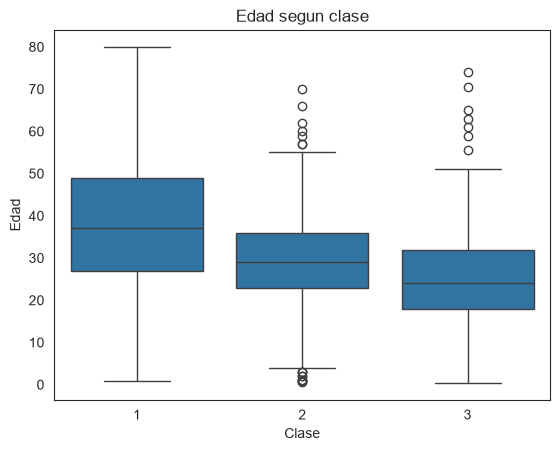

In [15]:
# Escriba aquí su código
sns.boxplot(data = titanic, x = "Pclass", y = "Age")
plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad segun clase")



**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [16]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?                        La mayoridad viajaba sola
- Hay grupos familiares muy grandes?                                            Sí hay grupos hasta 11 personas
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?    no es casi la misma distribucion


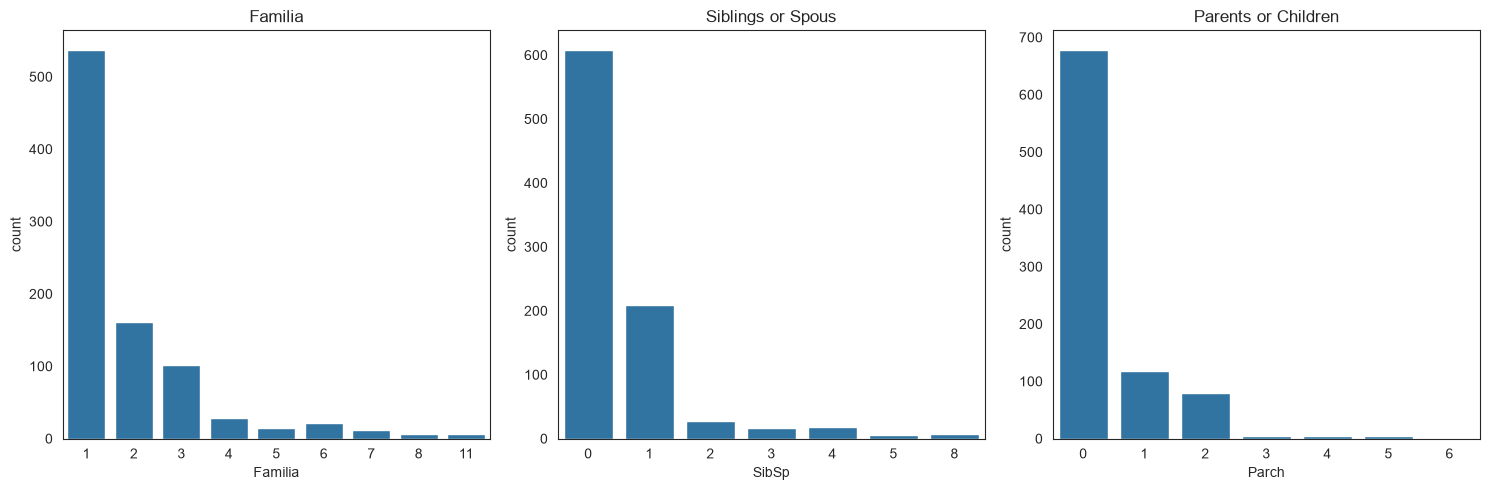

In [17]:
# Escriba aquí su código
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data = titanic, x = "Familia", ax=axes[0])
axes[0].set_title("Familia")
sns.countplot(data = titanic, x = "SibSp", ax=axes[1])
axes[1].set_title("Siblings or Spous")
sns.countplot(data = titanic, x = "Parch", ax=axes[2])
axes[2].set_title("Parents or Children")

plt.tight_layout()
plt.show()


# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


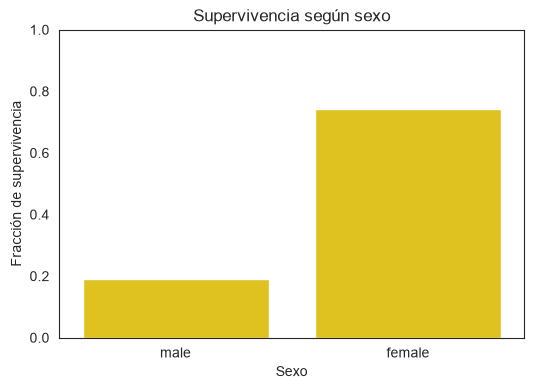

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?

1. no, no es similar, es muy mas alto para mujeres
2. No eso no nos permite asumir algo sobre las razones de la diferencia!


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?            Sí hay differencias
- Existe una tendencia?                             en tercera clase, la tasa de supervivencia es menos de la mitad en comparación con la primera clase


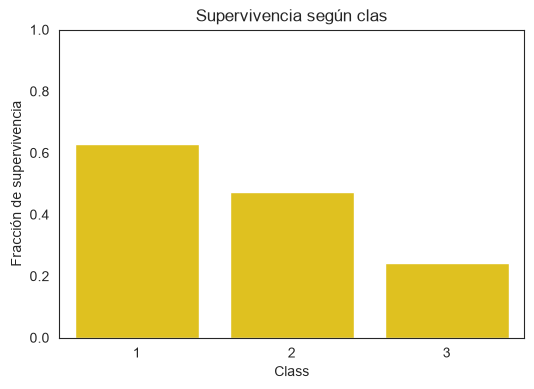

In [19]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')

plt.xlabel("Class")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clas")
plt.ylim(0,1)

plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?                          Sí, a medida que aumenta la edad, la tasa de supervivencia disminuye
- Hay algún grupo de edad que llame particularmente su atención?            sobre todos las más jóvenes tienen la mayor tasa de supervivencia 


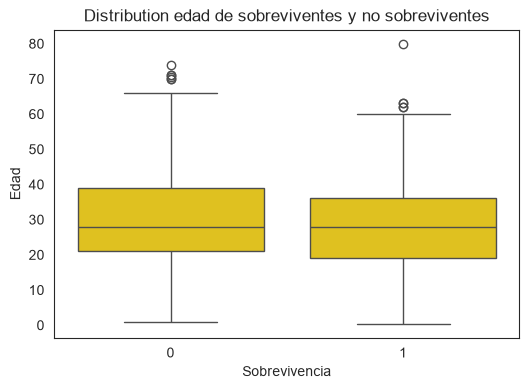

In [20]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.boxplot(data=titanic, x="Survived", y="Age", color='gold')

plt.xlabel("Sobrevivencia")
plt.ylabel("Edad")
plt.title("Distribution edad de sobreviventes y no sobreviventes")

plt.show()

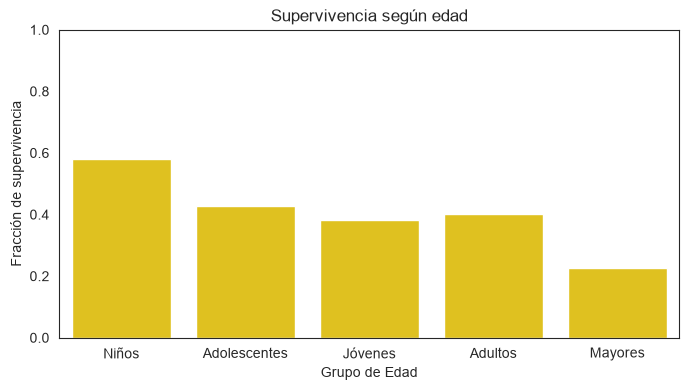

In [33]:
titanic["Age_Group"] = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Niños", "Adolescentes", "Jóvenes", "Adultos", "Mayores"],
)

# 2. Plot erstellen
plt.figure(figsize=(8, 4))
sns.barplot(
    data=titanic,
    x="Age_Group",
    y="Survived",
    errorbar=None,
    color="gold",
)

plt.xlabel("Grupo de Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad")
plt.ylim(0, 1)

plt.show()

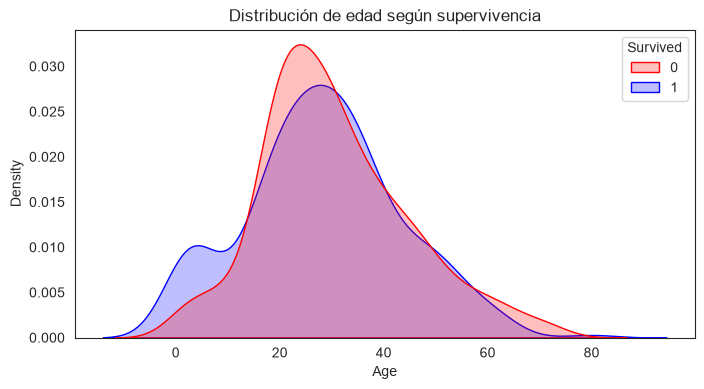

In [34]:
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=titanic,
    x="Age",
    hue="Survived",
    common_norm=False,
    fill=True,
    palette=["red", "blue"],
)
plt.title("Distribución de edad según supervivencia")
plt.show()

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?      desfavorable!!
- La relación parece simple?                        No, por un tamaño de la familia desde 1 hasta 4 aumenta la tasa, pero después hay una fuerte caída 
- Qué ocurre con los grupos familiares grandes?     familias de 7 personass tienen una supervivencia grande, pero las families con aun mas personas tienen una sobrevivencia muy pequenio!!


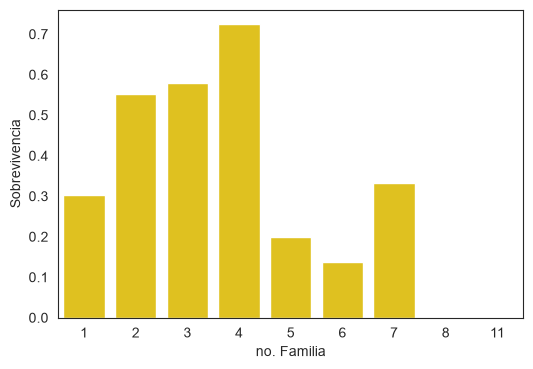

In [39]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar = None, color='gold')

plt.ylabel("Sobrevivencia")
plt.xlabel("no. Familia")

plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


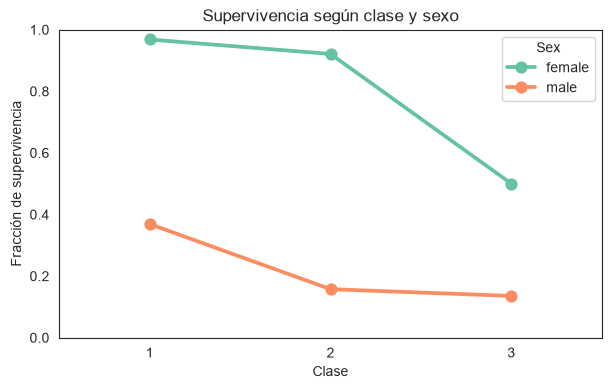

In [22]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?      la supervivencia desminuya de clase 1 a 3 pero para mujeres clase 1 y 2 son parecidos, mientras en clase 3 la sobrevivencia es mucho menor. Para hombres la tasa baja mas entre clase 1 y 2, mientras 2 y 3 sosn parecido.
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?  mujeres en clase 1 y 2 son favorecido. mujeres en clase 3 tienen una supervivencia muy menor que en las otras clases. hombres en clase 2 y 3 son muy desfavorecido



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [40]:
# Complete el código

conditions = [
    titanic["Age"] < 16,
    titanic["Sex"] == "female",  # bzw. 'mujer'
]
choices = ["niño/a", "mujer"]

titanic["Persona"] = np.select(conditions, choices, default="hombre")
# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


<Axes: xlabel='Persona', ylabel='Survived'>

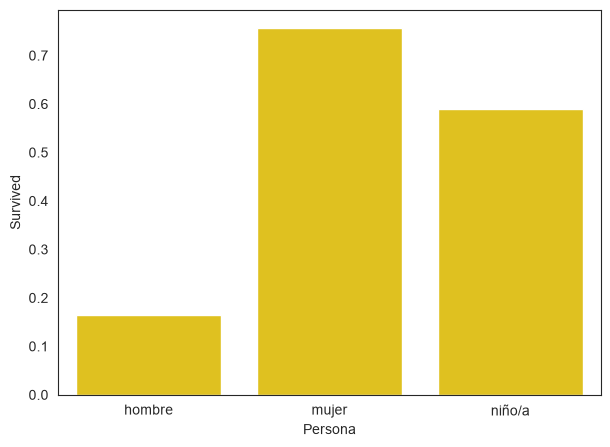

In [42]:
plt.figure(figsize = (7,5))

sns.barplot(data=titanic, x="Persona", y="Survived", errorbar=None, color="gold")

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


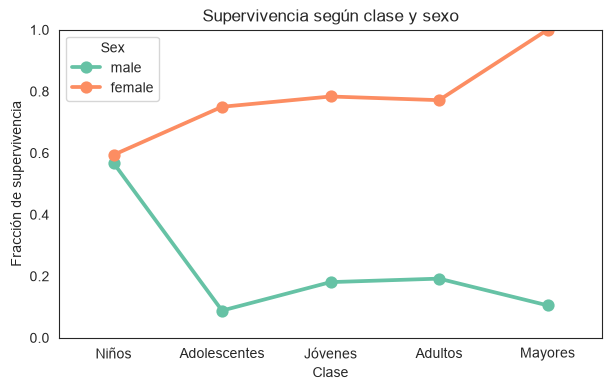

In [44]:
# Pregunta: what is the influence of the age on the survivalrate with regard to the sex

# Código:

plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Age_Group",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**
--> Podría ser que las mujeres y los niños sean más resistentes al frío o que sean mejores nadadores

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo: la mayoridad eran hombres (app. 65%)
- clase: la moyoria viajaba en tercera clase (>50%) sguido por la primera y leug la segunda clase.
- edad: concentration del edad enntre 20-35 años con poco myores o niños
- tamaño de familia: la gran mayoridad viajaba sola.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.
Los mujers tuvieron una supervivencia mas alta que los hombres (>70% vs <20%>). Ademas viajar en clase 1 aumentó drasticamente la probabilidad de sobreviviencia. 1. clase > 2. clase >3. clase.
los niós tuvieron una mayo probabilidad de sobrevivir en comparasion con los adultos. Y viajar solo o en familias con mas de 5 personas reducía la probabilidad de sobrevivir, mientras que una tamaño de famila de 2-4 personas resultaba beneficioso


### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.
los mayores que son mujeres tenian una probabilidad muy alto de sobrevivir. Lo cual contrasta con el hecho de que, en general, las personas mayores tienen una tasa de supervivencia más baja

### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.

Explicación: Existe una correlación directa e intuitiva entre ambas variables. Los pasajeros de primera clase pagaron tarifas significativamente más altas en comparación con los de segunda y tercera clase. Ambas variables capturan esencialmente el mismo factor subyacente: el nivel socioeconómico del pasajero.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

La relación entre el tamaño del grupo familiar (Familia) y la tasa de supervivencia no es lineal: mientras que viajar en familias pequeñas (2 a 4 integrantes) aumentó la supervivencia respecto a viajar solo, en familias de más de 4 personas la tasa cayó drásticamente a valores cercanos al 10–15%.

Viajar con una familia muy numerosa o con muchos niños podría estar asociado con un estatus social más bajo, lo que apunta más bien a la clase 3 y, por lo tanto, a menores posibilidades de supervivencia

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*

... era mujer, de edad joven/adulto o mayor. viajaba en la primera clase y en una familia de 2 a 4 personas.